In [1]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [6]:
font_list = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
print("설치된 나눔 폰트 목록:", font_list)

설치된 나눔 폰트 목록: ['Nanum Myeongjo', 'Nanum Gothic', 'Nanum Brush Script']


In [9]:
!pip install ruptures

Defaulting to user installation because normal site-packages is not writeable


In [10]:
#변화전 감지
import ruptures as rpt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [12]:
#데이터준비
signal = np.concatenate([
    np.random.normal(0,1,100),
    np.random.normal(5,1,100)
])


#편균 변화 감지
algo= rpt.Pelt(model = 'rbf', min_size =3, jump = 5)
changepoints = algo.fit(signal).predict(pen=10)

In [13]:
#데이터 생성
np.random.seed(1)
m1= np.concatenate([
    np.random.normal(0,1,100),  # 평균 = 0
    np.random.normal(5,1,100)   # 평균 = 5
])
time = np.arange(len(m1))

#편균 변화 감지
algo= rpt.Pelt(model = 'rbf').fit(m1)
changepoints = algo.fit(signal).predict(pen=10)

print(f'변화점: {changepoints}')
print(f'변화 횟수 : {len(changepoints) -1}개')

변화점: [100, 200]
변화 횟수 : 1개


# HAR DATA CHANGE POINT ANALYSIS

In [14]:
#load drive location
import os

#데이터 결로 확인
data_path = os.path.join(os.getcwd(), 'data','A_DeviceMotion_data')
if os.path.exists(data_path):
    print(f"데이터 경로 확인: {data_path}")
else:
    print("경로를 찾을 수 없습니다.")

데이터 경로 확인: /Users/linerenza/Desktop/비정형데이터분석/data/A_DeviceMotion_data


In [16]:
#har_total.pkl을 하나의 Dataframe으로 로드
har_total_path = os.path.join(data_path, 'HAR_total.pkl')
if os.path.exists(har_total_path):
    with open(har_total_path, 'rb') as f:
        har_data = pickle.load(f)
    print("HAR_total.pkl 파일이 성공적으로 로드되었습니다.")
else:
    print("HAR_total.pkl 파일을 찾을 수 없습니다.") 
display(har_data.head())

HAR_total.pkl 파일이 성공적으로 로드되었습니다.


,Unnamed: 0,attitude.roll,attitude.pitch,attitude.yaw,gravity.x,gravity.y,gravity.z,rotationRate.x,rotationRate.y,rotationRate.z,userAcceleration.x,userAcceleration.y,userAcceleration.z,exp_no,id,activity,maguserAcceleration,magrotationRate
0,0,-2.116381,-1.077507,-2.261502,-0.404768,0.880780,0.245713,-1.264215,-1.027909,-0.947909,0.282683,-0.254346,-0.407670,11,12,dws,0.557491,1.885038
1,1,-2.148154,-1.049759,-2.284278,-0.417081,0.867303,0.271686,-1.162024,-0.269118,-0.848823,0.256712,0.079154,-0.560291,11,12,dws,0.621363,1.463976
2,2,-2.153824,-1.026749,-2.297008,-0.432082,0.855621,0.284961,-0.665042,0.520170,-0.726722,0.253600,0.346680,-0.463275,11,12,dws,0.631762,1.113994
3,3,-2.142509,-1.012749,-2.290595,-0.445311,0.848291,0.286507,-0.079809,0.055322,-0.604534,0.411818,0.459372,-0.510293,11,12,dws,0.800635,0.612284
4,4,-2.130486,-1.007262,-2.274149,-0.452661,0.845372,0.283600,0.456097,-0.186877,-0.441315,0.311594,0.477305,-0.925049,11,12,dws,1.086566,0.661594


In [17]:
#데이터 타입 변환
har_data['id'] = har_data['id'].astype(str)
har_data['exp_no'] = har_data['exp_no'].astype(str)

#그룹화 및 변화점 분석
experiments = har_data.groupby(['id', 'exp_no', 'activity'])
ch_pt_results = []

for (subject_id, exp_no, activity), group_data in experiments:
    mag_rotation = group_data[ 'magrotationRate'].values
    mag_acceleration = group_data['maguserAcceleration'].values

    try:
        # 변화점 계산 (cp1~cp6)
        #펴뉸 변화, 하나의 변화점 구간에 속해야하는 샘플 수 10개, 5개 씩 건너뛰면서 변화점을 찾음
        #변화점 갯수에 pin = 20
        algo_mean = rpt.Binseg(model ='l2', min_size = 10, jump = 5)
        #마지막 원소로 데이터의 전체 길이 (끝 지점)을 포함하기 때문에 -1
        cp_mean_rot = len(algo_mean.fit(mag_rotation).predict(pen = 20)) -1
        cp_mean_acc = len(algo_mean.fit(mag_acceleration).predict(pen = 20)) -1

        #분산 변화
        algo_var = rpt.Binseg(model = 'normal', min_size = 10, jump = 5)
        cp_var_rot = len(algo_var.fit(mag_rotation).predict(pen=20)) -1
        cp_var_acc =len(algo_var.fit(mag_acceleration).predict(pen=20)) -1

        #기울기 변화
        #기울기 변화 김지용 - 시간축 추가해서 2D로 만들기
        n_rot = len(mag_rotation)
        n_acc = len(mag_acceleration)

        # 2D 신호 만들기 (시간, 값)
        signal_rot = np.column_stack([np.arange(n_rot), mag_rotation]) # 선형 회귀 (y = ax+b)로 만들거라서
        # np.arange(n_rot)
        # → 0부터 n_rot-1까지 1씩 증가하는 배열 생성 (예: [0, 1, 2, 3, ...])
        # → 시간축 (x축) 역할

        # mag_rotation
        # → 실제 회전 신호 값 (예: [0.5, 0.7, 1.2, 0.9, ...])
        # → 데이터 값 (y축) 역할

        # np.column_stack((..., ...))
        # → 두 개의 1차원 배열을 열(column) 기준으로 붙여서
        # → (시간, 값) 형태의 2차원 배열 생성
        signal_acc = np.column_stack((np.arange(n_acc), mag_acceleration))

        # 변화점 탐지 (기울기 기반)
        algo_slope = rpt.Binseg(model="linear", min_size=10, jump=5)

        # 변화점 개수 계산
        cp_slope_rot = len(algo_slope.fit(signal_rot).predict(n_bkps=3)) - 1
        cp_slope_acc = len(algo_slope.fit(signal_acc).predict(n_bkps=3)) - 1

        ch_pt_results.append({
            'id': subject_id,          # 피험자 ID
            'exp_no': exp_no,          # 실험 번호
            'activity': activity,      # 수행한 활동 (예: 걷기, 뛰기 등)

            # 평균 기반 변화점
            'cp1': cp_mean_rot,        # 회전 신호 평균 변화점 개수
            'cp2': cp_mean_acc,        # 가속도 신호 평균 변화점 개수

            # 분산 기반 변화점
            'cp3': cp_var_rot,         # 회전 신호 분산 변화점 개수
            'cp4': cp_var_acc,         # 가속도 신호 분산 변화점 개수

            # 기울기 기반 변화점
            'cp5': cp_slope_rot,       # 회전 신호 기울기 변화점 개수
            'cp6': cp_slope_acc        # 가속도 신호 기울기 변화점 개수
            })
    except Exception as e:
        print(f"Error : {e}")
        continue


In [19]:
#결과를 dataframe으로 변환
ch_pt = pd.DataFrame(ch_pt_results)
display(ch_pt)

#결과 저장
csv_path = f"{data_path}/HAR_CP_Analysis.csv"
pkl_path = f"{data_path}/HAR_CP_Analysis.pkl"

ch_pt.to_csv(csv_path, index=False)
ch_pt.to_pickle(pkl_path)

print("저장 완료")

,id,exp_no,activity,cp1,cp2,cp3,cp4,cp5,cp6
0,1,1,dws,0,0,1,5,3,3
1,1,11,dws,0,0,2,1,3,3
2,1,12,ups,3,0,2,5,3,3
3,1,13,sit,0,0,216,141,3,3
4,1,14,std,0,0,49,24,3,3
...,...,...,...,...,...,...,...,...,...
355,9,5,sit,0,0,214,125,3,3
356,9,6,std,0,0,215,134,3,3
357,9,7,wlk,3,1,8,10,3,3
358,9,8,wlk,0,0,1,3,3,3


저장 완료


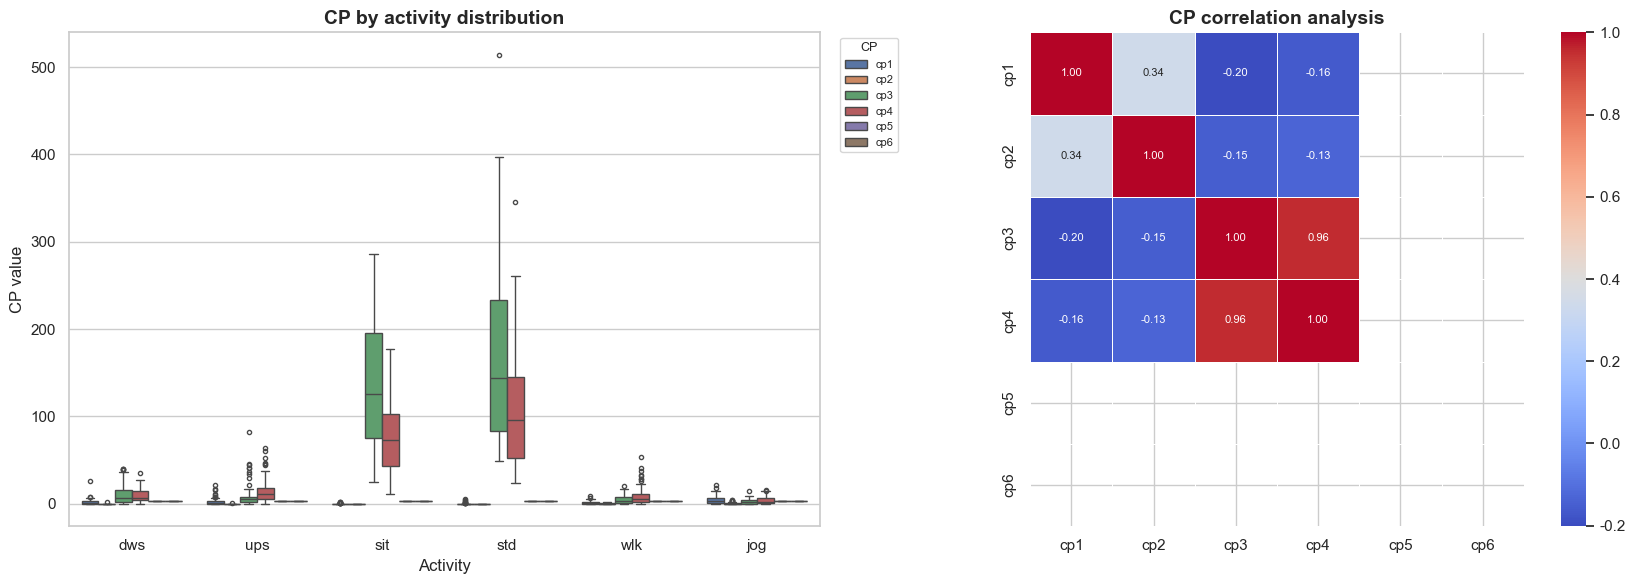

In [20]:
df = ch_pt.copy()
cp_cols = ['cp1', 'cp2', 'cp3', 'cp4', 'cp5', 'cp6']

df_long = df.melt(
    id_vars='activity',
    value_vars=cp_cols,
    var_name='CP Feature',
    value_name='CP Value'
)

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sns.boxplot(
    data=df_long,
    x='activity',
    y='CP Value',
    hue='CP Feature',
    dodge=True,
    fliersize=3,
    linewidth=1,
    ax=axes[0]
)
axes[0].set_title("CP by activity distribution", fontsize=14, weight='bold')
axes[0].set_xlabel("Activity")
axes[0].set_ylabel("CP value")
axes[0].legend(title="CP", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title_fontsize=9)

corr = df[cp_cols].corr()
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    annot_kws={"size": 8},
    ax=axes[1]
)
axes[1].set_title("CP correlation analysis", fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

# 데이터 준비

In [21]:
# 1. 데이터 로드
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# 데이터 로드
df = pd.read_csv(data_path + '/HAR_CP_Analysis.csv')

# 특징 및 타겟 분리
X = df[['cp1', 'cp2', 'cp3', 'cp4','cp5','cp6']].values
y = df['activity'].values
le = LabelEncoder()
y = le.fit_transform(y)
groups = df['id'].astype(str).values

# 2. GroupShuffleSplit으로 학습/테스트 분할 (누출 방지)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# 3. 표준화 (선형 모델 사용 시)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 모델 설정

In [24]:
# 모델 불러오기
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 모델 정의
models = {
    'RF': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42
    ),

    'XGB': XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        random_state=42
    ),

    'LGBM': LGBMClassifier(
        n_estimators=400,
        num_leaves=31,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity = -1
    )
}

# 교차검증 설정
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    cv_scores[name] = scores.mean()
    print(f"{name}: {scores.mean():.3f} (+/- {scores.std():.3f})")

best_name = max(cv_scores, key=cv_scores.get)
best_model = models[best_name]
best_model.fit(X_train, y_train)

print(f"\n최고 모델: {best_name} (정확도: {cv_scores[best_name]:.3f})")


RF: 0.505 (+/- 0.077)
XGB: 0.488 (+/- 0.041)
LGBM: 0.435 (+/- 0.065)

최고 모델: RF (정확도: 0.505)


In [25]:
print(df[['cp1', 'cp2', 'cp3', 'cp4', 'cp5', 'cp6']].isnull().sum())
print(df[['cp1', 'cp2', 'cp3', 'cp4', 'cp5', 'cp6']].describe())
print(df[['cp1', 'cp2', 'cp3', 'cp4', 'cp5', 'cp6']].nunique())
print(df['activity'].value_counts())
print(df.groupby('activity')['id'].nunique())

cp1    0
cp2    0
cp3    0
cp4    0
cp5    0
cp6    0
dtype: int64
              cp1         cp2         cp3         cp4    cp5    cp6
count  360.000000  360.000000  360.000000  360.000000  360.0  360.0
mean     1.958333    0.175000   46.883333   31.655556    3.0    3.0
std      3.507404    0.558487   81.294867   48.298609    0.0    0.0
min      0.000000    0.000000    0.000000    0.000000    3.0    3.0
25%      0.000000    0.000000    2.000000    4.000000    3.0    3.0
50%      0.000000    0.000000    7.000000   11.000000    3.0    3.0
75%      3.000000    0.000000   54.250000   37.000000    3.0    3.0
max     26.000000    4.000000  514.000000  346.000000    3.0    3.0
cp1     20
cp2      5
cp3    111
cp4    106
cp5      1
cp6      1
dtype: int64
activity
dws    72
ups    72
wlk    72
sit    48
std    48
jog    48
Name: count, dtype: int64
activity
dws    24
jog    24
sit    24
std    24
ups    24
wlk    24
Name: id, dtype: int64


Accuracy: 0.440
Macro F1-Score: 0.422

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.20      0.26        15
           1       0.44      0.80      0.57        10
           2       0.40      0.40      0.40        10
           3       0.44      0.40      0.42        10
           4       0.27      0.20      0.23        15
           5       0.58      0.73      0.65        15

    accuracy                           0.44        75
   macro avg       0.42      0.46      0.42        75
weighted avg       0.42      0.44      0.41        75



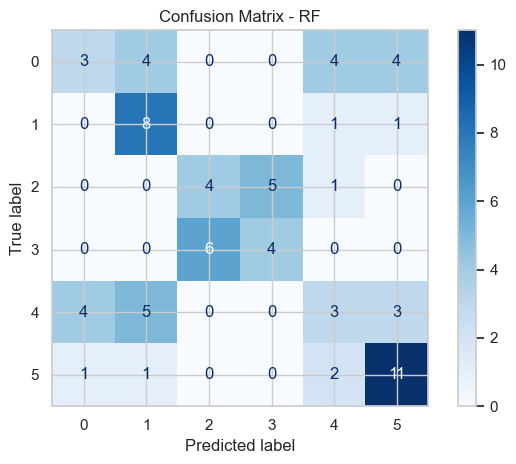

In [26]:
# 필요한 평가 함수 불러오기
from sklearn.metrics import (
    accuracy_score,        # 정확도
    f1_score,              # F1-score
    classification_report,# 상세 리포트
    ConfusionMatrixDisplay
)

# 예측
y_pred = best_model.predict(X_test)

# 성능 계산
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

# 결과 출력
print(f"Accuracy: {acc:.3f}")
print(f"Macro F1-Score: {f1:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix 시각화
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap='Blues'
)

plt.title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.show()

change point analysis 결과 검증 정확도는 45.3%만 나옴

## change point 분석과 peak 분석 데이터과 예측

In [28]:
peak_data = pd.read_csv(data_path + '/HAR_Peak_Analysis.csv')
display(peak_data)

,sequence_key,exp_no,id,activity,f_n,p_interval,p_interval_std,p_mean,p_max,p_min,p_std,cfr,cfa
0,exp_1_id_1_dws,1,1,dws,67,25.909091,18.497174,4.821695,7.138682,4.013819,0.571169,2.992226,3.456021
1,exp_1_id_10_dws,1,10,dws,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.549224,3.510066
2,exp_1_id_11_dws,1,11,dws,16,128.866667,157.651907,4.151319,4.465340,4.000085,0.147131,2.201655,4.153525
3,exp_1_id_12_dws,1,12,dws,90,16.865169,18.395399,5.146957,9.340254,4.006383,1.263152,3.289149,5.318040
4,exp_1_id_13_dws,1,13,dws,46,34.777778,33.163431,4.464274,5.246849,4.025133,0.328732,2.238085,3.934568
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,exp_9_id_5_jog,9,5,jog,239,14.840336,6.217551,5.076605,7.039267,4.016397,0.443038,2.304248,3.116643
356,exp_9_id_6_jog,9,6,jog,590,7.178268,5.779432,5.948539,17.601996,4.002710,1.658114,4.732604,4.789707
357,exp_9_id_7_jog,9,7,jog,343,13.190058,9.114882,4.981133,6.970203,4.000603,0.693778,2.398520,3.987310
358,exp_9_id_8_jog,9,8,jog,19,218.277778,266.954899,4.191888,4.640206,4.021614,0.175551,2.318616,3.830996


In [29]:
# 데이터 타입 불일치 해결: exp_no와 id를 문자열로 통일
peak_data['exp_no'] = peak_data['exp_no'].astype(str)
peak_data['id'] = peak_data['id'].astype(str)
ch_pt['exp_no'] = ch_pt['exp_no'].astype(str)
ch_pt['id'] = ch_pt['id'].astype(str)

# 데이터 병합
final_df = pd.merge(
    peak_data,
    ch_pt,
    on=["exp_no", "id", "activity"],
    how="inner"
)

print(f"병합된 데이터 형태: {final_df.shape}")
display(final_df.head())

병합된 데이터 형태: (360, 19)


,sequence_key,exp_no,id,activity,f_n,p_interval,p_interval_std,p_mean,p_max,p_min,p_std,cfr,cfa,cp1,cp2,cp3,cp4,cp5,cp6
0,exp_1_id_1_dws,1,1,dws,67,25.909091,18.497174,4.821695,7.138682,4.013819,0.571169,2.992226,3.456021,0,0,1,5,3,3
1,exp_1_id_10_dws,1,10,dws,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.549224,3.510066,1,0,12,22,3,3
2,exp_1_id_11_dws,1,11,dws,16,128.866667,157.651907,4.151319,4.465340,4.000085,0.147131,2.201655,4.153525,0,0,0,9,3,3
3,exp_1_id_12_dws,1,12,dws,90,16.865169,18.395399,5.146957,9.340254,4.006383,1.263152,3.289149,5.318040,2,0,3,2,3,3
4,exp_1_id_13_dws,1,13,dws,46,34.777778,33.163431,4.464274,5.246849,4.025133,0.328732,2.238085,3.934568,1,0,3,2,3,3


In [30]:
feature_cols = [
    col for col in final_df.columns
    if col not in ["sequence_key", "exp_no", "id", "activity"]
]
# 결측치는 0으로 채워 학습용 행렬 생성
X = final_df[feature_cols].fillna(0.0)

# 예측 대상은 activity 라벨
y = final_df['activity'].values
le = LabelEncoder()
y = le.fit_transform(y)
groups = final_df['id'].astype(str).values

# 2. GroupShuffleSplit으로 학습/테스트 분할 (누출 방지)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

# pandas DataFrame에서는 iloc을 사용하여 행을 선택해야 합니다.
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# 3. 표준화 (선형 모델 사용 시)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
# 교차검증 설정
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    cv_scores[name] = scores.mean()
    print(f"{name}: {scores.mean():.3f} (+/- {scores.std():.3f})")

best_name = max(cv_scores, key=cv_scores.get)
best_model = models[best_name]
best_model.fit(X_train, y_train)

print(f"\n최고 모델: {best_name} (정확도: {cv_scores[best_name]:.3f})")


RF: 0.639 (+/- 0.082)
XGB: 0.660 (+/- 0.100)
LGBM: 0.632 (+/- 0.084)

최고 모델: XGB (정확도: 0.660)


Accuracy: 0.547
Macro F1-Score: 0.533

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.27      0.32        15
           1       0.48      1.00      0.65        10
           2       0.50      0.50      0.50        10
           3       0.44      0.40      0.42        10
           4       0.62      0.53      0.57        15
           5       0.83      0.67      0.74        15

    accuracy                           0.55        75
   macro avg       0.54      0.56      0.53        75
weighted avg       0.56      0.55      0.54        75



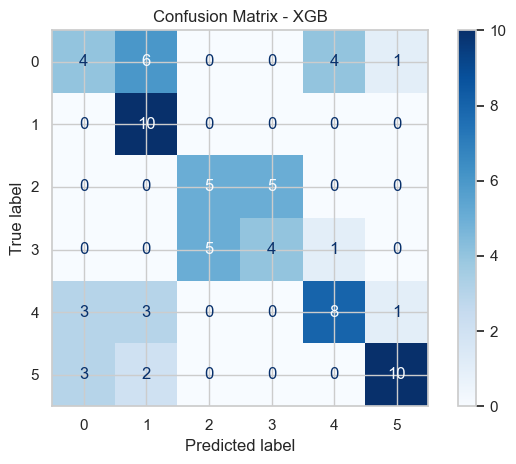

In [32]:
# 필요한 평가 함수 불러오기
from sklearn.metrics import (
    accuracy_score,        # 정확도
    f1_score,              # F1-score
    classification_report,# 상세 리포트
    ConfusionMatrixDisplay
)

# 예측
y_pred = best_model.predict(X_test)

# 성능 계산
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

# 결과 출력
print(f"Accuracy: {acc:.3f}")
print(f"Macro F1-Score: {f1:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix 시각화
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap='Blues'
)

plt.title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.show()

change point analysis과 peak analysis 변수를 feature로 사용하는 결과 검증 정확도가 52%만 나옴

## Change point analysis, peak analysis 그리고 statistical feature analysis

In [34]:
statistical_analysis = pd.read_csv(data_path + '/HAR_Statistical_Analysis.csv')
display(statistical_analysis)

,id,exp_no,activity,magAcc_mean,magAcc_sd,magAcc_skew,magAcc_rms,magAcc_rss,magAcc_iqr,magAcc_kurt,magRot_mean,magRot_sd,magRot_skew,magRot_rms,magRot_rss,magRot_iqr,magRot_kurt
0,1,1,dws,0.501065,0.262767,1.140624,0.565750,23.673799,0.336092,5.204329,2.050740,1.219460,0.803248,2.385742,99.831278,1.705448,3.011956
1,1,11,dws,0.508985,0.279252,1.499335,0.580483,17.375745,0.331943,7.360827,2.079373,1.218075,0.726392,2.409531,72.125131,1.719327,2.915536
2,1,12,ups,0.480549,0.265723,1.511764,0.549062,17.926694,0.343959,8.182422,2.474843,1.302956,0.800285,2.796596,91.307900,1.838639,3.350890
3,1,13,sit,0.017672,0.015293,5.197941,0.023370,2.370859,0.010806,54.387429,0.044123,0.066350,4.943210,0.079679,8.083395,0.036880,38.845216
4,1,14,std,0.025681,0.017401,1.863807,0.031019,1.567308,0.018296,7.560645,0.078551,0.075889,2.236386,0.109211,5.518133,0.085203,10.373218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,9,5,sit,0.017991,0.028522,15.155193,0.033721,3.556707,0.011594,325.852805,0.022275,0.075582,14.227161,0.078793,8.310674,0.014400,302.308539
356,9,6,std,0.039642,0.029047,2.580146,0.049144,4.303369,0.033015,16.939298,0.100096,0.124112,3.258778,0.159440,13.961669,0.094865,20.110048
357,9,7,wlk,0.718710,0.455437,1.650330,0.850845,71.713708,0.527404,7.327457,2.057096,0.962778,0.349108,2.271223,191.430523,1.421875,2.634247
358,9,8,wlk,0.773928,0.487419,1.600238,0.914599,63.060922,0.582684,7.240736,2.156300,0.966396,0.401919,2.362912,162.921028,1.348324,2.869443


In [35]:
# 데이터 타입 통일 (exp_no와 id를 문자열로 변환)
final_df['exp_no'] = final_df['exp_no'].astype(str)
final_df['id'] = final_df['id'].astype(str)
statistical_analysis['exp_no'] = statistical_analysis['exp_no'].astype(str)
statistical_analysis['id'] = statistical_analysis['id'].astype(str)

# 데이터 병합
final_df2 = pd.merge(
    final_df,
    statistical_analysis,
    on=["exp_no", "id", "activity"],
    how="inner"
)

print(f"병합된 데이터 형태: {final_df2.shape}")
display(final_df2.head())

병합된 데이터 형태: (360, 33)


,sequence_key,exp_no,id,activity,f_n,p_interval,p_interval_std,p_mean,p_max,p_min,...,magAcc_rss,magAcc_iqr,magAcc_kurt,magRot_mean,magRot_sd,magRot_skew,magRot_rms,magRot_rss,magRot_iqr,magRot_kurt
0,exp_1_id_1_dws,1,1,dws,67,25.909091,18.497174,4.821695,7.138682,4.013819,...,23.673799,0.336092,5.204329,2.050740,1.219460,0.803248,2.385742,99.831278,1.705448,3.011956
1,exp_1_id_10_dws,1,10,dws,0,0.000000,0.000000,0.000000,0.000000,0.000000,...,25.255740,0.305495,5.379826,1.356675,0.727939,0.575066,1.539566,79.671614,1.060385,2.709283
2,exp_1_id_11_dws,1,11,dws,16,128.866667,157.651907,4.151319,4.465340,4.000085,...,26.006686,0.322821,8.579478,1.804294,0.926519,0.491217,2.028174,91.267846,1.435859,2.346286
3,exp_1_id_12_dws,1,12,dws,90,16.865169,18.395399,5.146957,9.340254,4.006383,...,42.830102,0.600444,15.225889,2.542101,1.266006,1.026925,2.839718,110.785394,1.664675,5.429483
4,exp_1_id_13_dws,1,13,dws,46,34.777778,33.163431,4.464274,5.246849,4.025133,...,32.955450,0.509161,5.120770,2.101499,1.039398,0.440124,2.344347,93.274385,1.471083,2.590042


In [36]:
# 전체 features
print(final_df2.columns)

Index(['sequence_key', 'exp_no', 'id', 'activity', 'f_n', 'p_interval',
       'p_interval_std', 'p_mean', 'p_max', 'p_min', 'p_std', 'cfr', 'cfa',
       'cp1', 'cp2', 'cp3', 'cp4', 'cp5', 'cp6', 'magAcc_mean', 'magAcc_sd',
       'magAcc_skew', 'magAcc_rms', 'magAcc_rss', 'magAcc_iqr', 'magAcc_kurt',
       'magRot_mean', 'magRot_sd', 'magRot_skew', 'magRot_rms', 'magRot_rss',
       'magRot_iqr', 'magRot_kurt'],
      dtype='object')


In [37]:
feature_cols = [
    col for col in final_df2.columns
    if col not in ["sequence_key", "exp_no", "id", "activity"]
]
# 결측치는 0으로 채워 학습용 행렬 생성
X = final_df2[feature_cols].fillna(0.0)

# 예측 대상은 activity 라벨
y = final_df2['activity'].values
le = LabelEncoder()
y = le.fit_transform(y)
groups = final_df2['id'].astype(str).values

# 2. GroupShuffleSplit으로 학습/테스트 분할 (누출 방지)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

# pandas DataFrame에서는 iloc을 사용하여 행을 선택해야 합니다.
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# 3. 표준화 (선형 모델 사용 시)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
# 교차검증 설정
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    cv_scores[name] = scores.mean()
    print(f"{name}: {scores.mean():.3f} (+/- {scores.std():.3f})")

best_name = max(cv_scores, key=cv_scores.get)
best_model = models[best_name]
best_model.fit(X_train, y_train)

print(f"\n최고 모델: {best_name} (정확도: {cv_scores[best_name]:.3f})")


RF: 0.867 (+/- 0.065)
XGB: 0.884 (+/- 0.049)
LGBM: 0.895 (+/- 0.053)

최고 모델: LGBM (정확도: 0.895)


Accuracy: 0.707
Macro F1-Score: 0.705

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.27      0.38        15
           1       0.67      1.00      0.80        10
           2       0.88      0.70      0.78        10
           3       0.75      0.90      0.82        10
           4       0.57      0.80      0.67        15
           5       0.85      0.73      0.79        15

    accuracy                           0.71        75
   macro avg       0.73      0.73      0.70        75
weighted avg       0.72      0.71      0.69        75



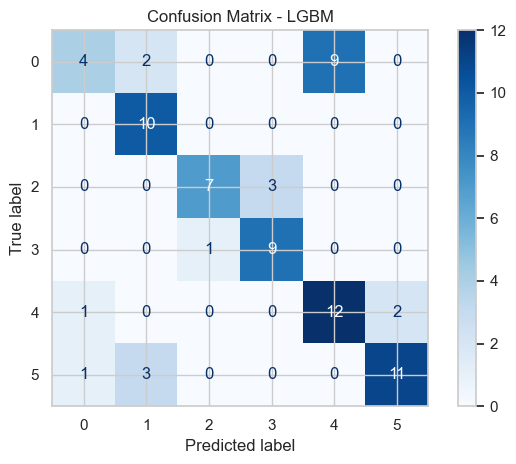

In [39]:
# 필요한 평가 함수 불러오기
from sklearn.metrics import (
    accuracy_score,        # 정확도
    f1_score,              # F1-score
    classification_report,# 상세 리포트
    ConfusionMatrixDisplay
)

# 예측
y_pred = best_model.predict(X_test)

# 성능 계산
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

# 결과 출력
print(f"Accuracy: {acc:.3f}")
print(f"Macro F1-Score: {f1:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix 시각화
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap='Blues'
)

plt.title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.show()

change point 분석, peak 분석, 그리고 통계 분석의 feature들이 다 학습할 떄 사용하면 검증할때 70.7% 나온다

train 정확도(89.5%)랑 차이가 많아서 모델이 overfitting 의심을 크다